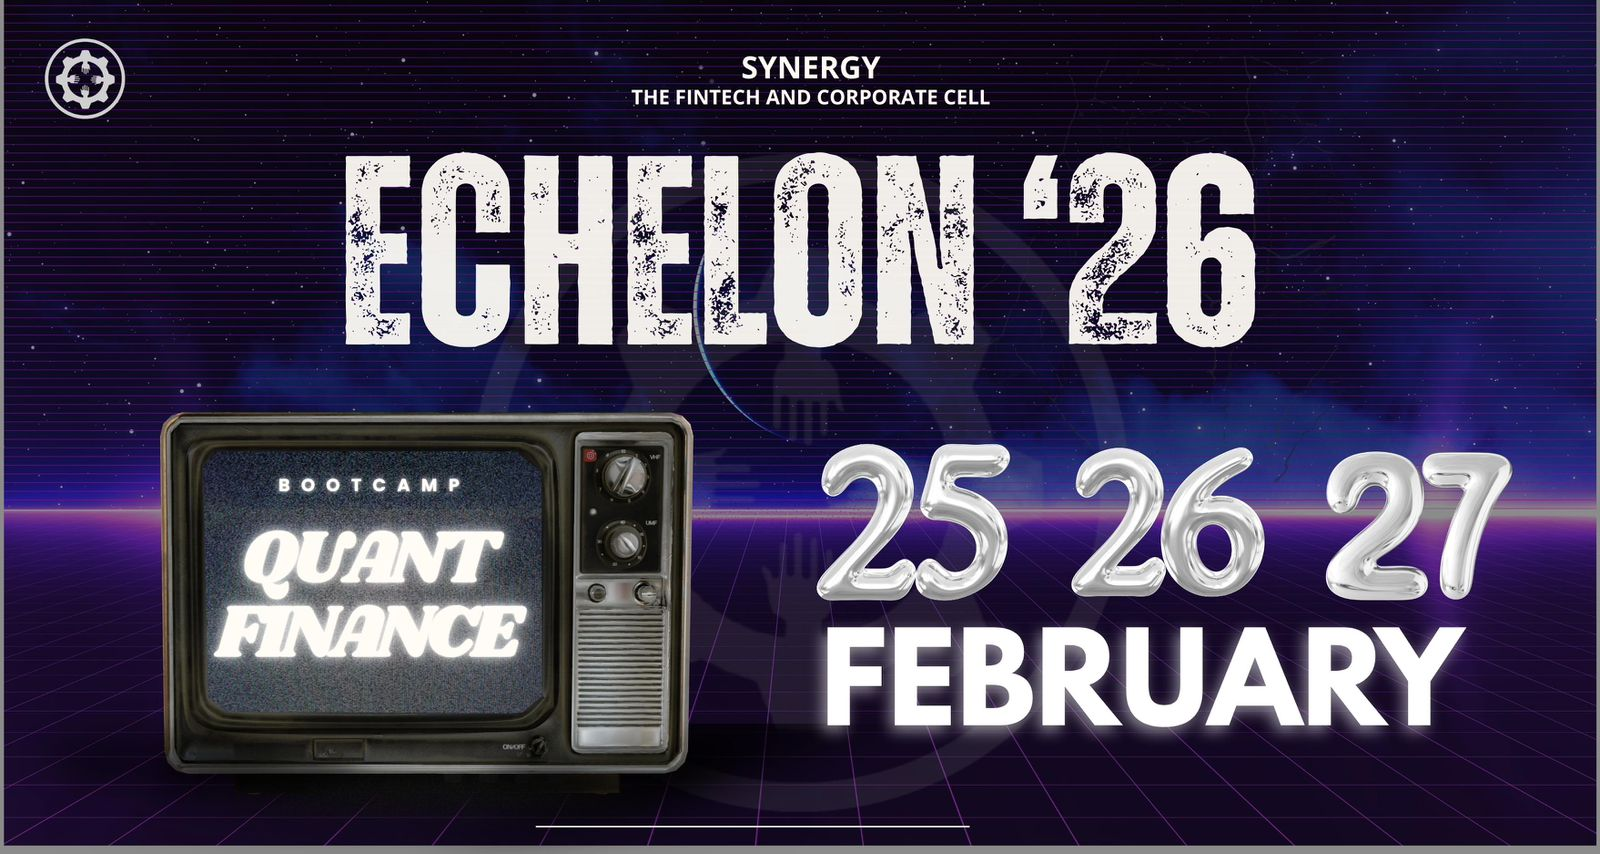

# Day 2 - Portfolio Theory & Optimization

---

# 1. Portfolio Mathematics

Let:

$
\mathbf{w} = (w_1, w_2, ..., w_n)
$

be portfolio weights.

Portfolio return:

$
R_p = \mathbf{w}^T \mathbf{R}
$

Expected return:

$
\mu_p = \mathbf{w}^T \boldsymbol{\mu}
$

Portfolio variance:

$
\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}
$

Where:

- $\boldsymbol{\mu}$ = expected return vector
- $\Sigma$ = covariance matrix

tickers = ["AAPL", "MSFT", "GOOG"]
data = yf.download(tickers, start="2018-01-01")["Adj Close"]

returns = np.log(data / data.shift(1)).dropna()

In [ ]:
mu = returns.mean()
cov_matrix = returns.cov()

mu, cov_matrix

In [ ]:
num_portfolios = 5000
results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    
    port_return = np.dot(weights, mu)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = port_return / port_vol
    
    results[0,i] = port_return
    results[1,i] = port_vol
    results[2,i] = sharpe

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap="viridis")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.colorbar(label="Sharpe Ratio")
plt.title("Efficient Frontier")
plt.show()

# 2. Sharpe Ratio

$
S = \frac{\mu_p - r_f}{\sigma_p}
$

If $ r_f = 0 $:

$
S = \frac{\mu_p}{\sigma_p}
$

We now maximize Sharpe ratio.

from scipy.optimize import minimize

def negative_sharpe(weights):
    port_return = np.dot(weights, mu)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return -port_return / port_vol

constraints = ({'type':'eq','fun': lambda x: np.sum(x)-1})
bounds = tuple((0,1) for _ in range(len(tickers)))

init_guess = len(tickers)*[1/len(tickers)]

opt = minimize(negative_sharpe, init_guess, method='SLSQP',
               bounds=bounds, constraints=constraints)

opt.x